# 🧠 EDA Dataset MRI Tumor Otak

Notebook ini melakukan *Exploratory Data Analysis (EDA)* terhadap dataset MRI Tumor Otak yang terdiri dari empat kelas utama: **glioma**, **meningioma**, **pituitary**, dan **notumor**. Tujuannya adalah untuk memahami karakteristik data, mengevaluasi kualitas gambar, serta merancang langkah preprocessing yang tepat sebelum tahap pelatihan model *deep learning*.

In [2]:
# 1 Import Library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import cv2

%matplotlib inline
tqdm.pandas()
print('Library siap digunakan.')

Library siap digunakan.


In [3]:
# 2 Struktur Dataset
base_dir = 'dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

classes = os.listdir(train_dir)
print(f"Kelas yang tersedia: {classes}")

train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
test_counts = {cls: len(os.listdir(os.path.join(test_dir, cls))) for cls in classes}

train_df = pd.DataFrame(list(train_counts.items()), columns=['Kelas', 'Jumlah_Train'])
test_df = pd.DataFrame(list(test_counts.items()), columns=['Kelas', 'Jumlah_Test'])

display(train_df.merge(test_df, on='Kelas'))

Kelas yang tersedia: ['glioma', 'meningioma', 'notumor', 'pituitary']


,Kelas,Jumlah_Train,Jumlah_Test
0,glioma,1297,324
1,meningioma,1420,355
2,notumor,1600,400
3,pituitary,1406,351


C:\Users\asus\AppData\Local\Temp\ipykernel_58216\2217699519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette='pastel')


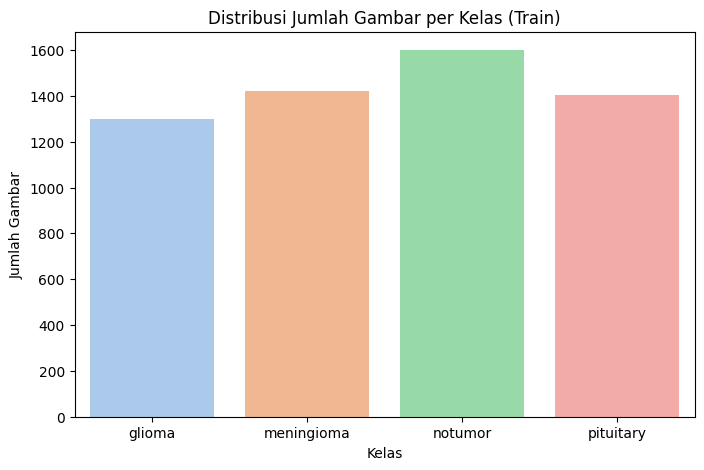

In [4]:
# 3 Visualisasi Distribusi Data
plt.figure(figsize=(8,5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette='pastel')
plt.title('Distribusi Jumlah Gambar per Kelas (Train)')
plt.ylabel('Jumlah Gambar')
plt.xlabel('Kelas')
plt.show()

Contoh gambar untuk kelas: glioma


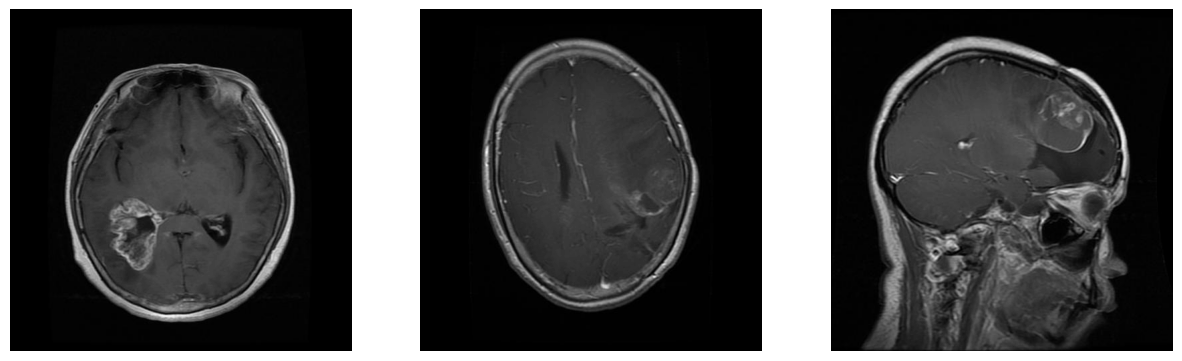

Contoh gambar untuk kelas: meningioma


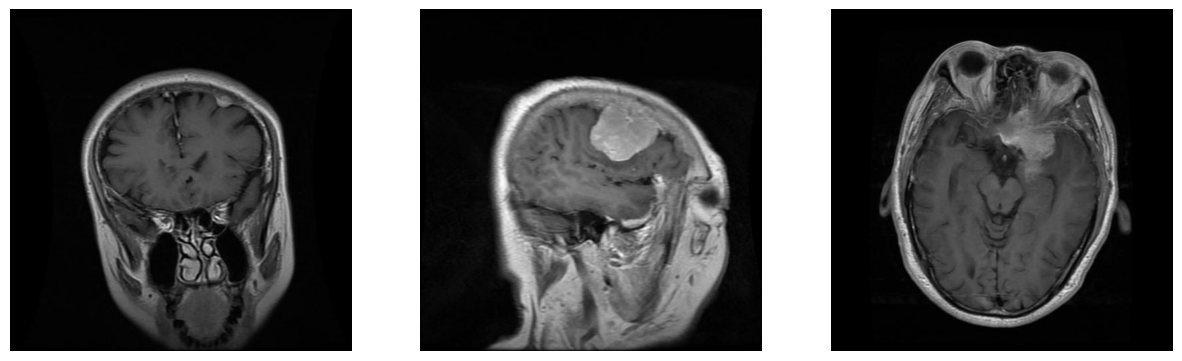

Contoh gambar untuk kelas: notumor


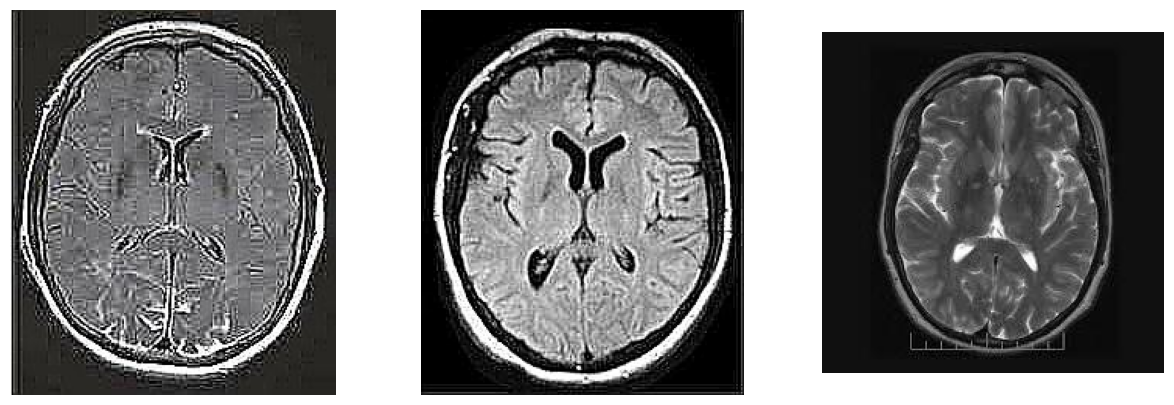

Contoh gambar untuk kelas: pituitary


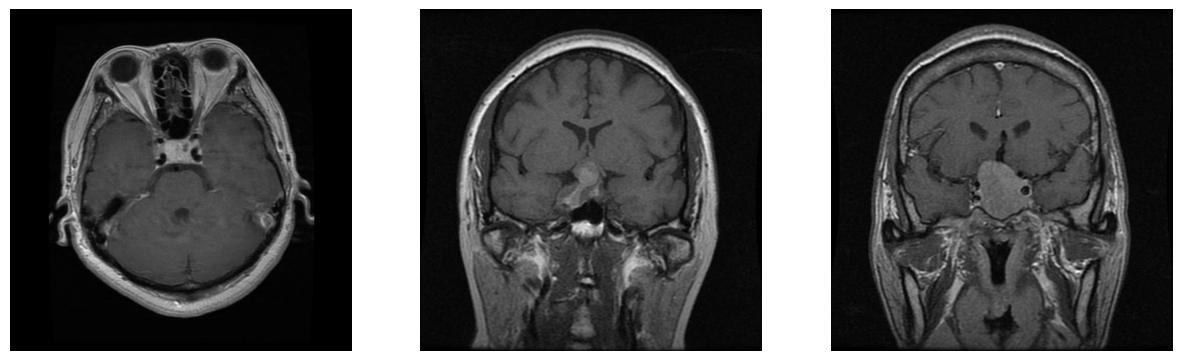

In [5]:
# 4 Contoh Gambar per Kelas
def tampilkan_contoh(folder_path, jumlah=3):
    plt.figure(figsize=(15,5))
    for i, img_name in enumerate(os.listdir(folder_path)[:jumlah]):
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path)
        plt.subplot(1, jumlah, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.show()

for cls in classes:
    print(f'Contoh gambar untuk kelas: {cls}')
    tampilkan_contoh(os.path.join(train_dir, cls))

100%|██████████| 4/4 [05:07<00:00, 76.90s/it]

Statistik Ukuran Gambar:


,Width,Height
count,5723.000000,5723.000000
mean,447.837847,450.213000
std,132.526077,126.277167
min,150.000000,168.000000
25%,414.000000,417.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1920.000000,1446.000000


Format unik: {'JPEG', 'PNG'}


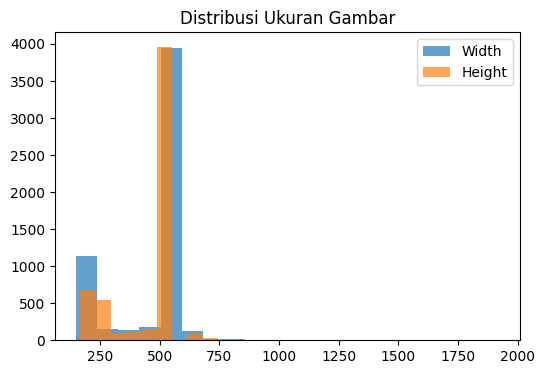

In [6]:
# 5 Analisis Ukuran dan Format Gambar
sizes = []
formats = []

for cls in tqdm(classes):
    folder = os.path.join(train_dir, cls)
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)
        try:
            img = Image.open(path)
            sizes.append(img.size)
            formats.append(img.format)
        except:
            print(f'Gagal membaca gambar: {path}')

sizes_df = pd.DataFrame(sizes, columns=['Width', 'Height'])
print('Statistik Ukuran Gambar:')
display(sizes_df.describe())
print(f'Format unik: {set(formats)}')

plt.figure(figsize=(6,4))
plt.hist([w for w,h in sizes], bins=20, alpha=0.7, label='Width')
plt.hist([h for w,h in sizes], bins=20, alpha=0.7, label='Height')
plt.legend()
plt.title('Distribusi Ukuran Gambar')
plt.show()

In [7]:
# 6 Cek Gambar Duplikat dan Corrupt
import hashlib

def hash_file(img_path):
    with open(img_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for cls in classes:
    folder = os.path.join(train_dir, cls)
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)
        try:
            h = hash_file(path)
            if h in hashes:
                duplicates.append((path, hashes[h]))
            else:
                hashes[h] = path
        except:
            continue

print(f'Jumlah duplikat terdeteksi: {len(duplicates)}')

Jumlah duplikat terdeteksi: 295
